In [1]:
import numpy
import matplotlib.pyplot as plt
import torch

print(torch.cuda.is_available())
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")
torch.get_default_device()

True


device(type='cuda', index=0)

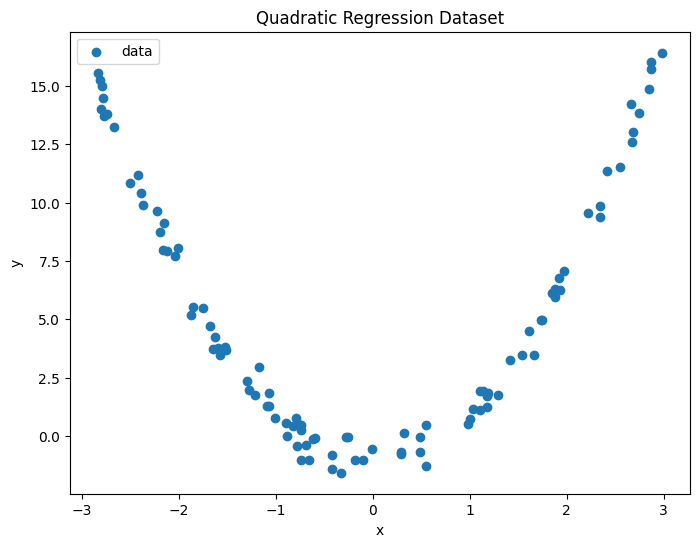

In [2]:
# データ準備（二次関数）
f = lambda x: 2 * x**2 - 1
x = numpy.random.rand(100, 1) * 6 - 3
noise = numpy.random.randn(100, 1) * 0.5
y = (f(x) + noise)

# 正規化（機械学習モデルは、あまり大きい値を扱うとモデル内部の計算が不安定になることがあるため、データを正規化することが一般的）
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()

def normalize(x,y):
    return (x - x_mean) / x_std, (y - y_mean) / y_std

def denormalize(x,y):
    return x * x_std + x_mean, y * y_std + y_mean

# plot 
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Regression Dataset')
plt.legend()
plt.show()

In [3]:
# define model
class Model(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=10, output_dim=1):
        super().__init__()
        self.f1 = torch.nn.Linear(input_dim, hidden_dim)  # input_dim=1, output_dim=10
        self.f2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.f3 = torch.nn.Linear(hidden_dim, output_dim)  # input_dim=10, output_dim=1

    def forward(self, x):
        # return self.linear(x)
        out = self.f1(x)  # (1,3)　行列かける
        out = torch.relu(out)  # 非線形な関数を通す
        out = self.f2(out) # (3,3)　行列かける
        out = torch.relu(out) # 非線形な関数を通す
        out = self.f3(out)  # (3,1)　行列かける
        return out
    


In [13]:
# define training loop
def train(
        model, 
        x_train, 
        y_train, 
        num_epochs=1000, 
        learning_rate=0.01):
    criterion = torch.nn.MSELoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # plot 
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train.cpu(), y_train.cpu(), label='data')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression Training')

    cmap = plt.get_cmap('viridis')

    loss_history = []

    for epoch in range(num_epochs):
        # training前の準備：モデルを訓練モードに設定し、勾配を初期化する
        model.train()
        optimizer.zero_grad()
        # training 開始
        outputs = model(x_train) # y_pred = f(x_train) 
        # loss = criterion(outputs, y_train)  # chi-equare: loss = (y_pred - y_train)^2
        # 自前実装
        loss = torch.mean((outputs - y_train) ** 2)
        loss.backward()  # 勾配計算
        loss_history.append(loss.detach().cpu().item())
        optimizer.step()

        # num_epochsの10%ごとに学習の進捗を表示
        if (epoch + 1) % (num_epochs // 10) == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_history[-1]:.4e}')

            # plot regression line
            with torch.no_grad():
                model.eval()
                predicted = model(x_train).detach().cpu().numpy()
            # plot用にデータをソート
            sorted_indices = x_train.cpu().numpy().argsort(axis=0).flatten()
            plt.plot(x_train.cpu().numpy()[sorted_indices], predicted[sorted_indices], label=f'Epoch {epoch+1}', color=cmap(epoch / num_epochs))

    return model, loss_history, plt.gcf()



Epoch [1000/10000], Loss: 9.3291e-03
Epoch [2000/10000], Loss: 8.3904e-03
Epoch [3000/10000], Loss: 8.0191e-03
Epoch [4000/10000], Loss: 7.8560e-03
Epoch [5000/10000], Loss: 7.8108e-03
Epoch [6000/10000], Loss: 7.7766e-03
Epoch [7000/10000], Loss: 7.7447e-03
Epoch [8000/10000], Loss: 7.7126e-03
Epoch [9000/10000], Loss: 7.6995e-03
Epoch [10000/10000], Loss: 7.6899e-03


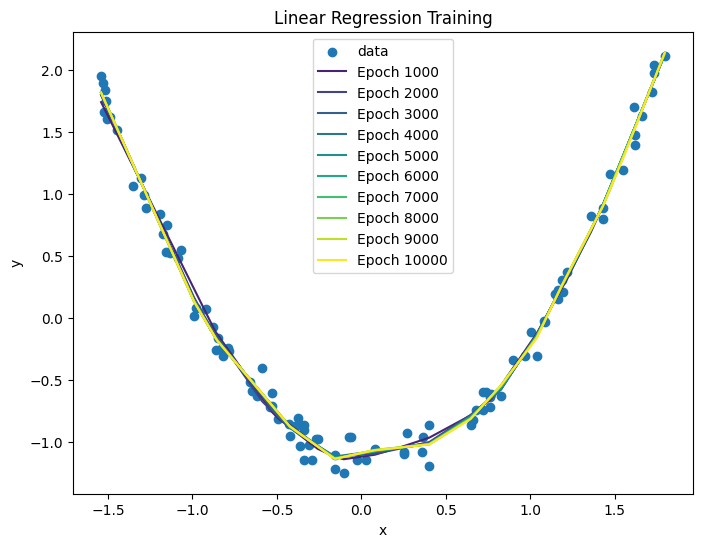

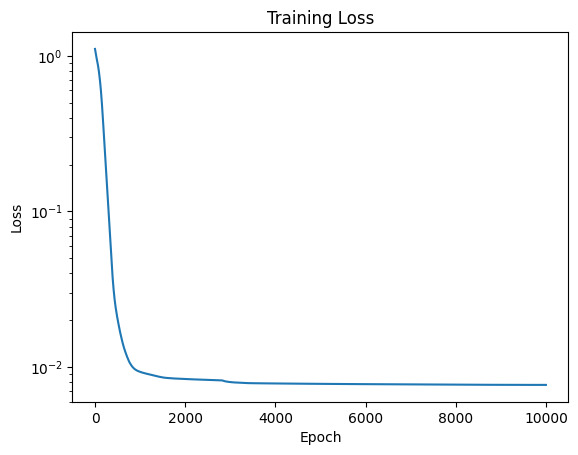

In [14]:
# training start
model = Model(hidden_dim=10)
x_train = torch.from_numpy(x).float().to("cuda")
y_train = torch.from_numpy(y).float().to("cuda")
x_train, y_train = normalize(x_train, y_train)
model, loss_history, _ = train(model, x_train, y_train, num_epochs=10000, learning_rate=0.001)
plt.legend()
plt.show()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training Loss')
plt.show()

Epoch [2000/20000], Loss: 7.0370e-03
Epoch [4000/20000], Loss: 6.1453e-03
Epoch [6000/20000], Loss: 5.1541e-03
Epoch [8000/20000], Loss: 4.1367e-03
Epoch [10000/20000], Loss: 3.7726e-03
Epoch [12000/20000], Loss: 3.5697e-03
Epoch [14000/20000], Loss: 3.1693e-03
Epoch [16000/20000], Loss: 3.3426e-03
Epoch [18000/20000], Loss: 3.0009e-03
Epoch [20000/20000], Loss: 2.9614e-03


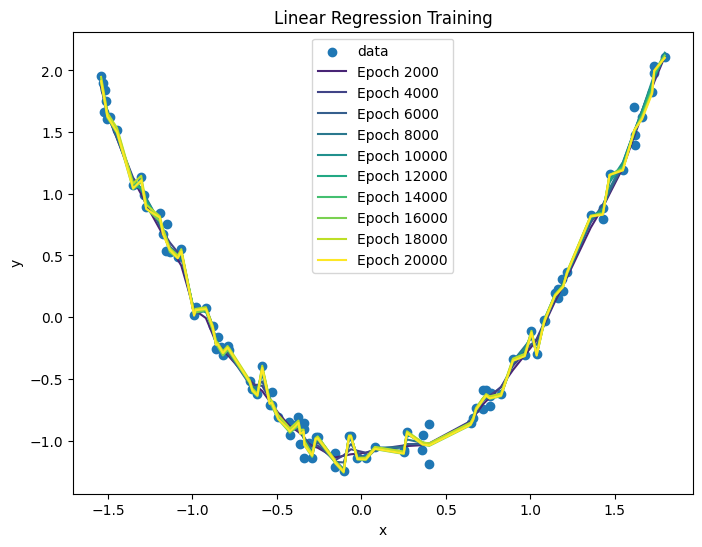

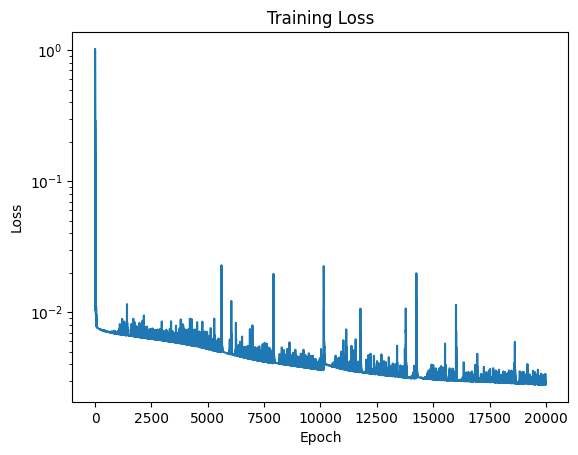

In [15]:
# オーバーフィッティングを確認するために、隠れ層の次元を増やしてみる
model = Model(hidden_dim=1000)
x_train = torch.from_numpy(x).float().to("cuda")
y_train = torch.from_numpy(y).float().to("cuda")
x_train, y_train = normalize(x_train, y_train)
# わざと過学習させるためにepochを多めに設定
model, loss_history, _ = train(model, x_train, y_train, num_epochs=20000, learning_rate=0.001)
plt.legend()
plt.show()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training Loss')
plt.show()

In [16]:
# オーバーフィッティング対策様に、Dropoutを追加してみる
class ModelWithDropout(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=10, output_dim=1, dropout_rate=0.1):
        super().__init__()
        self.f1 = torch.nn.Linear(input_dim, hidden_dim)
        self.f2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.f3 = torch.nn.Linear(hidden_dim, output_dim)
        self.dropout1 = torch.nn.Dropout(dropout_rate)
        self.dropout2 = torch.nn.Dropout(dropout_rate)
        
    def forward(self, x):
        out = self.f1(x)
        out = torch.relu(out)
        out = self.dropout1(out)  # Dropoutを適用
        out = self.f2(out)
        out = torch.relu(out)
        out = self.dropout2(out)  # Dropoutを適用
        out = self.f3(out)
        return out

Epoch [2000/20000], Loss: 1.0743e-02
Epoch [4000/20000], Loss: 8.5601e-03
Epoch [6000/20000], Loss: 8.8121e-03
Epoch [8000/20000], Loss: 1.0961e-02
Epoch [10000/20000], Loss: 7.8977e-03
Epoch [12000/20000], Loss: 7.8722e-03
Epoch [14000/20000], Loss: 9.2114e-03
Epoch [16000/20000], Loss: 8.5903e-03
Epoch [18000/20000], Loss: 6.9632e-03
Epoch [20000/20000], Loss: 6.6088e-03


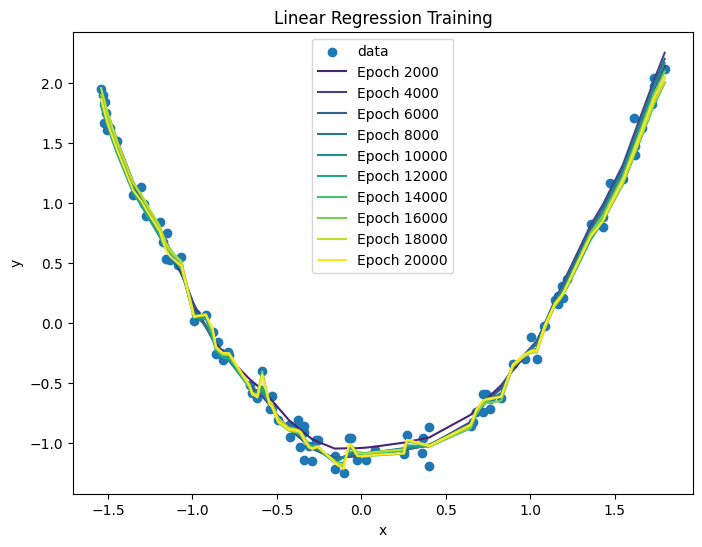

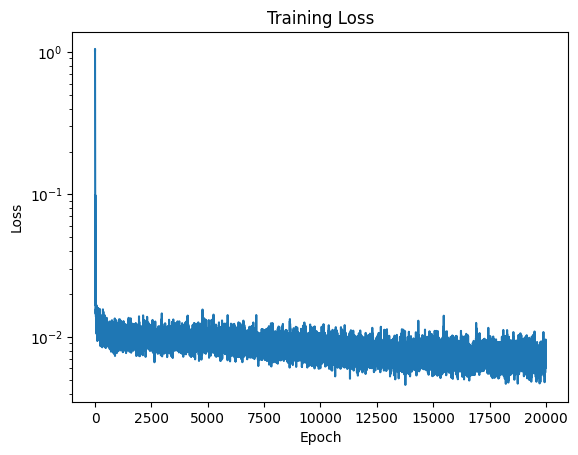

In [17]:
# オーバーフィッティングを確認するために、隠れ層の次元を増やしてみる
model = ModelWithDropout(hidden_dim=1000)
x_train = torch.from_numpy(x).float().to("cuda")
y_train = torch.from_numpy(y).float().to("cuda")
x_train, y_train = normalize(x_train, y_train)
# わざと過学習させるためにepochを多めに設定
model, loss_history, _ = train(model, x_train, y_train, num_epochs=20000, learning_rate=0.001)
plt.legend()
plt.show()
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

多少マイルドになった...?